### Built a basic chatbot with Langgraph (GRAPH API)


In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
  

In [2]:
# creating a state that is actually a shared memory by all the nodes 
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
  

In [3]:
import os
from dotenv import load_dotenv,find_dotenv
load_dotenv(find_dotenv())

True

In [4]:
#.chat_models import init_chat_model

# using chatgroq
#from langchain_groq import ChatGroq
#llm = ChatGroq(model="llma3-8b-8192")


#using init_chat_model
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",

)


In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021CB66FACF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021CB66FB770>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# creating a node functionality

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder =StateGraph(State)

#adding node to the graph

graph_builder.add_node("LLmChatbot", chatbot)

# Adding edges

graph_builder.add_edge(START,"LLmChatbot")
graph_builder.add_edge("LLmChatbot",END)

#compile the graph
graph = graph_builder.compile()

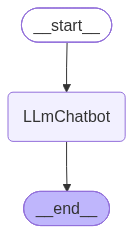

In [8]:
# visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
response = graph.invoke({"messages":"hi groq be bold and chill cold "})

In [10]:
response["messages"][-1].content

"**Hey, what's good?** I'm here to vibe with you. What's on your mind? Want to chat about something in particular or just shoot the breeze?"

### ChatBot with Tool

In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is genai?")

{'query': 'what is genai?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://en.wikipedia.org/wiki/Generative_AI',
   'title': 'Generative AI',
   'content': 'Generative artificial intelligence (GenAI) is a subfield of artificial intelligence (AI) that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.',
   'score': 0.93086797,
   'raw_content': None,
   'id': '944cd1-00'},
  {'url': 'https://www.cisco.com/site/us/en/learn/topics/artificial-intelligence/what-is-generative-ai-genai.html',
   'title': 'What is Generative Artificial Intelligence (GenAI)? - Cisco',
   'content': '# What is GenAI?\n\nGenerative AI (GenAI) is a branch of artificial intelligence that mimics human creativity to generate origina

In [12]:
# custom function 
def multiply(a:int,b:int)->int:
    """Multiply a and b

    args:
     a (int): first int 
     b (int): second int

    result:
     int: return output int

    """
    return a*b

In [13]:
tools = [tool,multiply]

In [14]:
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021CB66FACF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021CB66FB770>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

In [15]:
llm_with_tools.invoke("multiply 7 ,9")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '43nxp28t5', 'function': {'arguments': '{"a":7,"b":9}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1787, 'total_tokens': 1806, 'completion_time': 0.038342251, 'completion_tokens_details': None, 'prompt_time': 0.120345206, 'prompt_tokens_details': None, 'queue_time': 0.056038148, 'total_time': 0.158687457}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fe17a-e4a7-7501-9e16-d47bd0d3b717-0', tool_calls=[{'name': 'multiply', 'args': {'a': 7, 'b': 9}, 'id': '43nxp28t5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1787, 'output_tokens': 19, 'total_tokens': 1806})

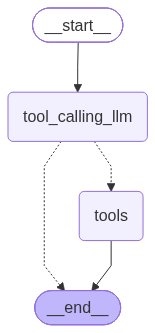

In [16]:
#Stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


#graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#add edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

# graph compile

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass



In [17]:
response=graph.invoke({"messages":"what is new in the field of ai skills?"})

print(response['messages'][-1].content)

{"query": "new developments in AI skills", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://today.iu.edu/live/news/51893-2-new-courses-build-off-genai-101-to-help-instructors-", "title": "2 new courses build off GenAI 101 to help instructors expand AI skills - IU Today", "content": "“IU’s AI Academy is a leader in creating engaging, high-impact courses to help learners develop AI skills,” said Peter Ermey, manager of learning experiences and media innovation for IU’s Instructional Design Innovation team. “These new courses move beyond the introduction to the topic in GenAI 101 to offer practical, hands-on techniques to integrate AI into educational workflows and improve student outcomes.”\n\nGenAI for Instructional Design is designed for instructors and instructional designers who want to explore how generative AI can support course design and content development. The course is broken out into five modules: [...] # IU Today\n\nIU Today News for st

In [18]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is new in the field of ai skills?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8qzbvmhk1)
 Call ID: 8qzbvmhk1
  Args:
    query: new developments in AI skills
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "new developments in AI skills", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://today.iu.edu/live/news/51893-2-new-courses-build-off-genai-101-to-help-instructors-", "title": "2 new courses build off GenAI 101 to help instructors expand AI skills - IU Today", "content": "“IU’s AI Academy is a leader in creating engaging, high-impact courses to help learners develop AI skills,” said Peter Ermey, manager of learning experiences and media innovation for IU’s Instructional Design Innovation t

In [19]:
response=graph.invoke({"messages":"what is 2 multiply 7?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiply 7?
================================== Ai Message ==================================
Tool Calls:
  multiply (ydrrvcvkb)
 Call ID: ydrrvcvkb
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: multiply

14


### ReAct Agent

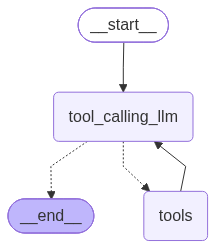

In [20]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


#graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#add edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# graph compile

graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [21]:
response=graph.invoke({"messages":"give me the recent ai news and then multiply 7 by 9?"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news and then multiply 7 by 9?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (5a75ng127)
 Call ID: 5a75ng127
  Args:
    query: AI news
    time_range: day
  multiply (c0krdhsps)
 Call ID: c0krdhsps
  Args:
    a: 7
    b: 9
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-company-accused-favoring-foreigners-over-american-workers", "title": "Fox News AI Newsletter: AI company accused of favoring foreigners over American workers", "content": "#### Paidwork breach exposes 23M user records\n Foreign robot ban targets China over security fears\n\n  #### Foreign robot ban targets China over security fears\n Fox News AI Newsletter: AI

### Adding memory in agentic graph

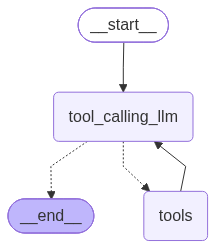

In [22]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


#graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

#add edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

# graph compile

graph = builder.compile(checkpointer=memory)

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [23]:
config = {"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"my name is ahtasham ansari"},config=config)
response['messages'][-1].content

"Based on the search result, it appears that Ahtasham Ansari is a financial leader with experience in audit, financial advisory, and talent management. He has worked with global firms and has held leadership positions in various organizations. He is also recognized as one of the top CEOs in the Middle East and serves on the Dubai Chamber of Commerce Board and as Vice Chairman of the Foreign Exchange & Remittance Group (FERG).\n\nWould you like to know more about Ahtasham Ansari's background or his current role?"

### Streaming

In [25]:

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def superbot(state=State):
    return {"messages":[llm.invoke(state["messages"])]}




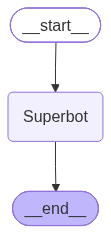

In [26]:
graph = StateGraph(State)

#node 
graph.add_node("Superbot",superbot)

#edges 
graph.add_edge(START,"Superbot")
graph.add_edge("Superbot",END)

#compile 

graph_build =graph.compile(checkpointer=memory)

#display
from IPython.display import display,Image
display(Image(graph_build.get_graph().draw_mermaid_png()))

In [ ]:
#invokation
config = 